<a href="https://colab.research.google.com/github/nthambire/pos_pucrj.ciencia-de-dados/blob/Machine-Learning/MVP_Breast_Cancer_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Nthambire Rodrigues Sabonete

**Matrícula:** _4052026000285_  
**Data:** _05/07/2026_  
**Dataset:** _Breast Cancer Wisconsin (Diagnostic) Dataset (link:  [kaggle.com/datasets/yasserh/breast-cancer-dataset](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset))_  
**Tipo de problema:** _Classificação_  

# 1. Definição do problema

## 1.1 Descrição do problema

O diagnóstico de um cancêr depende de análises detalhadas de exames clínicos, laboratoriais, imagens e biópsias, e o diganóstico quando mais cedo maior a porcentagem de um tratamento efetivo.


O diagnóstico precoce da doença possibilita que, com a descoberta em um estágio mais inicial, potencialmente curável, sejam utilizadas terapias mais simples e efetivas, ajudando na redução do estágio e melhorando a sobrevivência e a qualidade de vida do indivíduo.
Com isso, o objetivo deste código é classificar tumores com uma alta precisão, ajudando o médico responsável a ter maior efetividade no diagnóstico e para que o diagnpostico seja mais rápido e menos invasivo para o paciente, permitindo o início mais rápido do tratamento.



>Fonte de apoio: [Detecção Precoce - Instituto Nacional de Câncer - INCA
](https://www.inca.gov.br/sites/ufu.sti.inca.local/files/media/document/deteccao-precoce-do-cancer_0.pdf)


## 1.2 Objetivo do MVP

O objetivo deste MVP é desenvolver e avaliar um modelo de Machine Learning para classificação binária capaz de identificar de forma automatizada se um tumor de mama é maligno ou benigno a partir de características morfológicas celulares. Com isso, busca-se otimizar a métrica de *Recall* para fornecer aos oncologistas uma ferramenta ágil e segura de triagem secundária, apoiando o diagnóstico precoce e preciso da doença.

## 1.3 Tipo de problema

**Tipo escolhido:** _classificação_  
**Justificativa:** _este modelo busca prever uma variável categórica (benigno ou maligno)_

## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Hipótese 1:_ atributos que medem tamanho e irregularidade da célula (`radius_worst`, `perimeter_worst` e `area_worst`) são maiores em tumores malignos, permitindo o uso mair efetivo de modelos lineares de de margem;
2. _Hipótese 2:_ o uso de padronização aumentará a precisão e a convergência de modelos baseados em distânica (KNN) e gradiente (regressão logística);
3. _Hipótese 3:_ algoritmos cbaseados em árvore de decisão empilhadas capturarão melhor as interações não lineares dos dados sem sofrem com *overfitting*.

**Critérios de sucesso:**
- _Métrica principal:_ Recall dos dos tumores classificados como **malignos**, priorizando a redução de **falsos negativos** (avaliação em conjunto com *F1-score*).
- _Resultado mínimo esperado:_ Alcançar Recall mínimo de 90% na base de teste e superar o baseline em pelo menos 10%.
- _Restrição prática:_ um código simples e com baixo custo computacional, garantindo que o pipeline seja leve e rápido para que seja utilizado em computadores simples como os utilizados em clínicas médicas.


# 2. Ambiente, bibliotecas e reprodutibilidade


In [3]:

import os
import sys
import time
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub



from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.2 Funções auxiliares




In [4]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descrição da base escolhida.

- nome do dataset:  Breast Cancer Wisconsin (Diagnostic) Dataset
- link da fonte: [kaggle.com/datasets/yasserh/breast-cancer-dataset](https://kaggle.com/datasets/yasserh/breast-cancer-dataset)
- por que esse dataset foi escolhido: este dataset tem uma taxa alta deutilização no kaggle, póssui uma alta usabilidade por ter um detalhamento na descrição dos dados.
- quais restrições ou condições foram consideradas: este dataset possui apenas 569 instâncias, (exigindo validação cruzada estratificada para evitar overfitting), além de apresentar um desbalanceamento de classes (63% Benignos / 37% Malignos)
- questões de ética, privacidade, confidencialidade ou licença: os dados foram totalmente anonimizados na origem, respeitando a privacidade dos pacientes. O uso deste modelo é consultivo e não substitui laudos médicos que são soberanos. A base está sob a licença CC BY-NC-SA 4.0, permitindo o uso livre para fins acadêmicos e de estudo (como este MVP).


## 3.2 Carga dos dados



In [5]:

path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
print("Path do dataset:", path)

csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    df_path = csv_files[0]
    print(f"Carregando o arquivo: {os.path.basename(df_path)}")

    raw_data = pd.read_csv(df_path)
    df = raw_data.copy()

    df.rename(columns={df.columns[-1]: "diagnosis"}, inplace=True)

    print("Dados carregados com sucesso.")
else:
    print("Erro: Nenhum arquivo CSV foi encontrado.")

df.head()

Using Colab cache for faster access to the 'breast-cancer-dataset' dataset.
Path do dataset: /kaggle/input/breast-cancer-dataset
Carregando o arquivo: breast-cancer.csv
Dados carregados com sucesso.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,diagnosis
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3.3 Visão geral do dataset


- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [9]:
# Inspeção, Estrutura e Governança dos Dados

print("-" * 60)
print("1. DIMENSÕES DO DATASET")
print("-" * 60)
print(f"Quantidade de Linhas:  {df.shape[0]}")
print(f"Quantidade de Colunas: {df.shape[1]}")

df = df.loc[:,~df.columns.duplicated(keep='first')]
print("Colunas duplicadas foram tratadas")

print("\n" + "-" * 60)
print("2. TIPOS DOS ATRIBUTOS + VALORES AUSENTES ")
print("-" * 60)
info_df = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Ausentes (Qtd)': df.isnull().sum(),
    'Valores Ausentes (%)': ((df.isnull().sum() / len(df)) * 100).round(2)
})
display(info_df)

print("\n" + "-" * 60)
print("3. VERIFICAÇÃO DE DUPLICATAS")
print("-" * 60)
total_duplicadas = df.duplicated().sum()
print(f"Quantidade de linhas totalmente duplicadas: {total_duplicadas}")

print("\n" + "-" * 60)
print("4. ANÁLISE DE IDENTIFICADORES (IDs) OU VARIÁVEIS IRRELEVANTES")
print("-" * 60)
colunas_id = [col for col in df.columns if 'id' in col.lower() or 'index' in col.lower()]
if colunas_id:
    print(f" Colunas identificadas como possíveis IDs: {colunas_id}")
else:
    print("Nenhuma coluna foi mapeada por padrão de nome.")

print("\n" + "-" * 60)
print("5. DESCRIÇÃO DA VARIÁVEL ALVO (TARGET)")
print("-" * 60)
coluna_target = 'diagnosis'
if coluna_target in df.columns:
    print(f"Nome da variável alvo: '{coluna_target}'")

    contagem_absoluta = df[coluna_target].value_counts()
    contagem_percentual = (df[coluna_target].value_counts(normalize=True) * 100).round(2)

    target_summary = pd.DataFrame({
        'Contagem Absoluta': contagem_absoluta,
        'Percentual (%)': contagem_percentual
    })

    if set(target_summary.index).issubset({'M', 'B'}):
        target_summary.rename(index={'M': 'M (Maligno)', 'B': 'B (Benigno)'}, inplace=True)

    display(target_summary)


else:
    print(f"Alerta: A coluna target esperada '{coluna_target}' não foi encontrada no DataFrame.")

------------------------------------------------------------
1. DIMENSÕES DO DATASET
------------------------------------------------------------
Quantidade de Linhas:  569
Quantidade de Colunas: 31
Colunas duplicadas foram tratadas

------------------------------------------------------------
2. TIPOS DOS ATRIBUTOS + VALORES AUSENTES 
------------------------------------------------------------


,Tipo de Dado,Valores Ausentes (Qtd),Valores Ausentes (%)
id,int64,0,0.0
diagnosis,object,0,0.0
radius_mean,float64,0,0.0
texture_mean,float64,0,0.0
perimeter_mean,float64,0,0.0
area_mean,float64,0,0.0
smoothness_mean,float64,0,0.0
compactness_mean,float64,0,0.0
concavity_mean,float64,0,0.0
concave points_mean,float64,0,0.0



------------------------------------------------------------
3. VERIFICAÇÃO DE DUPLICATAS
------------------------------------------------------------
Quantidade de linhas totalmente duplicadas: 0

------------------------------------------------------------
4. ANÁLISE DE IDENTIFICADORES (IDs) OU VARIÁVEIS IRRELEVANTES
------------------------------------------------------------
 Colunas identificadas como possíveis IDs: ['id']

------------------------------------------------------------
5. DESCRIÇÃO DA VARIÁVEL ALVO (TARGET)
------------------------------------------------------------
Nome da variável alvo: 'diagnosis'


,Contagem Absoluta,Percentual (%)
diagnosis,,
B (Benigno),357,62.74
M (Maligno),212,37.26


## 3.4 Dicionário de dados



In [10]:

atributos_dados = {
    "Coluna": [
        "id",
        "radius_mean / _se / _worst",
        "texture_mean / _se / _worst",
        "perimeter_mean / _se / _worst",
        "area_mean / _se / _worst",
        "smoothness_mean / _se / _worst",
        "compactness_mean / _se / _worst",
        "concavity_mean / _se / _worst",
        "concave points_mean / _se / _worst",
        "symmetry_mean / _se / _worst",
        "fractal_dimension_mean / _se / _worst",
        "diagnosis"
    ],
    "Tipo": [
        "numérica (inteiro)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "alvo (categórica)"
    ],
    "Descrição": [
        "Código identificador exclusivo de cada paciente.",
        "Raio (média das distâncias do centro aos pontos do perímetro do núcleo).",
        "Textura (desvio padrão dos valores na escala de cinza dos píxeis).",
        "Tamanho total do perímetro do núcleo celular.",
        "Área espacial ocupada pelo núcleo da célula.",
        "Suavidade (variação local nos comprimentos dos raios).",
        "Compacidade (perímetro² / área - 1.0).",
        "Severidade das secções côncavas no contorno do núcleo.",
        "Quantidade de porções côncavas no contorno celular.",
        "Índice de simetria geométrica do núcleo.",
        "Dimensão fractal (aproximação da complexidade da borda).",
        "Diagnóstico clínico do tumor mapeado."
    ],
    "Será usada no modelo?": [
        "não", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "alvo"
    ],
    "Observações": [
        "Deve ser descartada; não possui poder preditivo e causaria sobreajuste.",
        "O valor '_worst' possui forte peso na separação de malignidade.",
        "Atributo importante para capturar irregularidades na superfície celular.",
        "Altamente correlacionado com o raio e a área (redundância geométrica).",
        "Possui escala numérica muito superior, exigindo padronização obrigatória.",
        "Valores baixos e alta irregularidade costumam indicar tumores malignos.",
        "Modela quão densa ou dispersa a estrutura do núcleo se apresenta.",
        "Indica a presença de deformações estruturais profundas na membrana.",
        "Mede o número absoluto de depressões e não a severidade delas.",
        "Células cancerígenas tendem a perder a simetria natural ao se multiplicarem.",
        "Avalia o nível de fragmentação periférica do núcleo da célula.",
        "Classe prevista: M (Maligno) ou B (Benigno). Será convertida para 1 ou 0."
    ]
}

df_atributos = pd.DataFrame(atributos_dados)
df_atributos.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Coluna,Tipo,Descrição,Será usada no modelo?,Observações
id,numérica (inteiro),Código identificador exclusivo de cada paciente.,não,Deve ser descartada; não possui poder preditivo e causaria sobreajuste.
radius_mean / _se / _worst,numérica (contínuo),Raio (média das distâncias do centro aos pontos do perímetro do núcleo).,sim,O valor '_worst' possui forte peso na separação de malignidade.
texture_mean / _se / _worst,numérica (contínuo),Textura (desvio padrão dos valores na escala de cinza dos píxeis).,sim,Atributo importante para capturar irregularidades na superfície celular.
perimeter_mean / _se / _worst,numérica (contínuo),Tamanho total do perímetro do núcleo celular.,sim,Altamente correlacionado com o raio e a área (redundância geométrica).
area_mean / _se / _worst,numérica (contínuo),Área espacial ocupada pelo núcleo da célula.,sim,"Possui escala numérica muito superior, exigindo padronização obrigatória."
smoothness_mean / _se / _worst,numérica (contínuo),Suavidade (variação local nos comprimentos dos raios).,sim,Valores baixos e alta irregularidade costumam indicar tumores malignos.
compactness_mean / _se / _worst,numérica (contínuo),Compacidade (perímetro² / área - 1.0).,sim,Modela quão densa ou dispersa a estrutura do núcleo se apresenta.
concavity_mean / _se / _worst,numérica (contínuo),Severidade das secções côncavas no contorno do núcleo.,sim,Indica a presença de deformações estruturais profundas na membrana.
concave points_mean / _se / _worst,numérica (contínuo),Quantidade de porções côncavas no contorno celular.,sim,Mede o número absoluto de depressões e não a severidade delas.
symmetry_mean / _se / _worst,numérica (contínuo),Índice de simetria geométrica do núcleo.,sim,Células cancerígenas tendem a perder a simetria natural ao se multiplicarem.


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [11]:
# Ajuste das variáveis conforme o dataset do MVP
TARGET = "diagnosis"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target (0 = Benigno, 1 = Maligno):")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target (0 = Benigno, 1 = Maligno):


,contagem
diagnosis,
B,357
M,212


,percentual
diagnosis,
B,62.74
M,37.26


In [12]:
# Separação de colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Remove o target da lista de atributos para a visualização
if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols





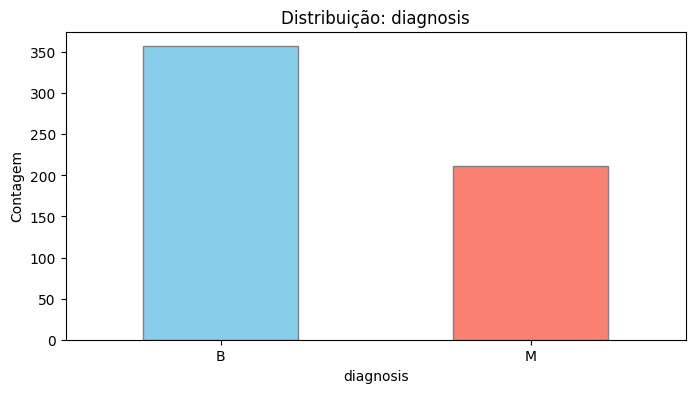

In [14]:

if categorical_cols:
    col = categorical_cols[0]
    plt.figure(figsize=(8, 4))

    counts = df[col].value_counts()

    cores_barras = ['skyblue' if x == 'B' else 'salmon' for x in counts.index]

    counts.plot(kind="bar", color=cores_barras, edgecolor="grey")

    plt.title(f"Distribuição: {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=0)
    plt.show()

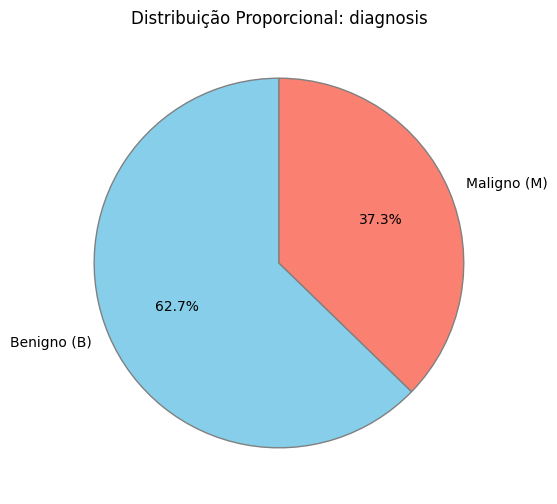

In [15]:
if TARGET in df.columns:
    plt.figure(figsize=(6, 6))

    target_counts = df[TARGET].value_counts()
    labels_mapeados = [ 'Maligno (M)' if x == 'M' else 'Benigno (B)' for x in target_counts.index]

    cores = ['salmon' if x == 'M' else 'skyblue' for x in target_counts.index]

    plt.pie(
        target_counts,
        labels=labels_mapeados,
        autopct='%1.1f%%',
        startangle=90,
        colors=cores,
        wedgeprops={'edgecolor': 'grey', 'linewidth': 1}
    )
    plt.title(f"Distribuição Proporcional: {TARGET}")
    plt.show()

## 4.1 Síntese da análise exploratória

 O target apresenta um desbalanceamento, com uma proporção de 62.74% para tumores benignos e 37.26% para malignos. Essa distribuição indica a necessidade de atenção na metrica de Recall. Além disso, não existem valores ausentes que sejam relevantes

Em relação à modelagem, a partir de dados de tamanho como `radius_worst`, `perimeter_worst`,`area_worst` são beneficiados por modelos lineares como regressão logística. Por outro lado, dados não lineares e mais complexos tendem a ser melhor avaliados através de algoritmos baseados em árvores, como o Random Forest.

A partir dos resultados da EDA, a recomendação técnica de remover a coluna id é ideal para mitigar o risco de overfitting. A análise validou a necessidade de incluir padronização de dados no pipeline e consolida a adoção do Recall de tumores malignos como critério essencial de sucesso médico de triagem.

## 5. Preparação dos dados para modelagem

Nesta seção, definiremos as variáveis de entrada (features) e a variável alvo (target), removeremos colunas irrelevantes e converteremos a variável alvo para um formato numérico. Em seguida, dividiremos o dataset em conjuntos de treino e teste para garantir a avaliação imparcial do modelo.

In [17]:
df_processed = df.drop(columns=['id'])

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

# Mapeamento da variável(Maligno = 1, Benigno = 0)
y = y.map({'M': 1, 'B': 0})

print("Features (X) e Target (y) definidos e target mapeado.")
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Features (X) e Target (y) definidos e target mapeado.
Shape de X: (569, 29)
Shape de y: (569,)


In [18]:
# Divisão dos dados em treino e teste (70% treino, 30% teste)
# Usamos stratify=y para manter a proporção das classes (M/B) em ambos os conjuntos,
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

print("Dados divididos em treino e teste.")
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Dados divididos em treino e teste.
Shape de X_train: (398, 29)
Shape de X_test: (171, 29)
Shape de y_train: (398,)
Shape de y_test: (171,)


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [22]:
# Comoas features são numéricas, o pipeline é aplicado diretamente ao dataset
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Prevenção para dados nulos
    ('scaler', StandardScaler())                  # Padronização (Média 0, Variância 1)
]).set_output(transform="pandas")                 # Mantém as colunas originais como DataFrame

## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> O **_holdout_** é utilizado para simular dados que o modelo não tenha sido apresentado ainda e a **validação cruzada** é aplicada para dar estabilidade aos testes considerando que o dataset é pequeno (569 amostras).

> A proporção teste garante que tenham dados suficientes para que o modelo aprenda com padrões sem sofrer com _underfitting_ ainda que reserve cerca de 114 amostras para avaliar o _Recall_

> Foi necessário usar a estratificação devido o desbalanceamento do target, que garante ue o teste mantenha a proporção e evitando ue a métrica de _Recall_ seja distorcida.

> Unindo a divisão do `pipeline` simplificado, o `SimpleImputer` e o `StandardScaler` calculam as estatísticas apenas com dados de treino, o cunjunto de teste é apenas tranformado. Isso garante uma barreira para que a triagem seja realista.


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.



In [24]:

# 1. Baseline (Dummy Classifier)
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

# 2. Modelo Candidato A: Regressão Logística
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=SEED, max_iter=1000))
])

# 3. Modelo Candidato B: Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=SEED))
])

# Treinando os modelos na base de treino
baseline_model.fit(X_train, y_train)
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

print("Todos os modelos foram treinados com sucesso!")

Todos os modelos foram treinados com sucesso!


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.


**Resposta:**  
> A escolha da **mediana** foi por ser uma métrica boa para lidar com outliers. Como as variáveis do dataset podem apresentar assimetrias extremas e valores distante do padrão, a média sofreria uma grande distorção enquanto a mediana preserva a tendência centrar dos dados.

> A padronização dos dados é necessária por conta da presença de variáveis com ordem de grandezas diferentes.

> A variável `id` foi removida por ser uma métrica de administração dos dados e não tem nenhum efeito causal na análise.




# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [33]:
# Avaliação e Comparação de Desempenho ===

models_dict = {
    "Baseline (Dummy)": model_lr, # Usando as predições para comparar
    "Regressão Logística": model_lr,
    "Random Forest": model_rf
}

classification_results = {}

# Avaliando no conjunto de Teste
for name, model in models_dict.items():
    if name == "Baseline (Dummy)":
        y_pred = baseline_model.predict(X_test)
        proba = None
    else:
        y_pred = model.predict(X_test)
        proba = model.predict_proba(X_test)

    metrics = evaluate_classification(y_test, y_pred, proba=proba)
    classification_results[name] = metrics

# Exibindo a tabela de comparação estruturada
df_results = show_results_table(classification_results)
display(df_results)

,accuracy,f1_weighted,roc_auc
Baseline (Dummy),0.625731,0.481678,NaN
Regressão Logística,0.970760,0.970611,0.997518
Random Forest,0.970760,0.970500,0.995108


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> O baseline é coerente por ser o marco zero do projeto, estabelecendo uma acurácia básica sem inteligência aplicada.

> O dataset utilizado é pequeno, com isso os modelos candidatos (regressão logística e  random forest) são adequados.
A regressão logística apresenta baixo risco de _overfitting_. O random forest é ideal para capturar interações não lineares complexas.

> A regressão logística exige escala. Como a função é fundamentada em combinações lineares e regularização, variáveis de altos valores dominariam o modelo sem o `StandardScaler`.

> Para o diagnóstico de um câncer é importante a interpretabilidade dos médicos por requesitos éticos e regulatórios.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.



In [29]:
print("Treinando o Modelo A (Regressão Logística)...")

# Ajusta/treina o pipeline da Regressão Logística
model_lr.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso.")

Treinando o Modelo A (Regressão Logística)...
Modelo de Regressão Logística treinado com sucesso.


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> Ambos os medelos alcançaram acima de 97% de acurácia, superando o dummy classifier.

> É o suficiente, porém  é otimizar o Recall para tumores malignos (reduzir falsos negativos)seria mais direto para o critério de sucesso.

>Nenhum modelo apresenta _overfitting_ por terem resultados das métricas de desempenho muito altas.

> O treinamento acontece em poucos segundos por ser uma base de dados pequena

>O resultado faz total sentido com o EDA: evitando _overfittng_, a padronização viabilizou o sucesso da regressão linear e o rendom forest capturou a omplexidade dos tumores.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [36]:
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define o scorer customizado para Recall da classe positiva (Maligno = 1)
recall_maligno_scorer = make_scorer(recall_score, pos_label=1)

# Define a distribuição de parâmetros para o RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': randint(50, 200),  # Número de árvores
    'classifier__max_depth': randint(5, 30),      # Profundidade máxima da árvore
    'classifier__min_samples_split': randint(2, 10), # Mínimo de amostras para dividir um nó
    'classifier__min_samples_leaf': randint(1, 5)   # Mínimo de amostras em uma folha
}

# Define a estratégia de validação cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Inicializa o RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=model_rf,  # Usa o pipeline do Random Forest como estimador
    param_distributions=param_dist,
    n_iter=20,           # Número de configurações de parâmetros a serem amostradas (ajustável)
    scoring=recall_maligno_scorer, # Usa o scorer customizado
    cv=cv_strategy,
    random_state=SEED,
    n_jobs=-1,           # Usa todos os cores disponíveis para paralelização
    verbose=2            # Exibe o progresso
)

print("Iniciando a busca de hiperparâmetros para Random Forest...")
random_search_rf.fit(X_train, y_train)

print("\nBusca de hiperparâmetros concluída.")
print(f"Melhores parâmetros encontrados: {random_search_rf.best_params_}")
print(f"Melhor Recall (Maligno) no cross-validation: {random_search_rf.best_score_:.4f}")

# Armazena o melhor estimador encontrado para uso futuro
model_rf_optimized = random_search_rf.best_estimator_
print("\nModelo Random Forest otimizado foi armazenado em 'model_rf_optimized'.")

Iniciando a busca de hiperparâmetros para Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Busca de hiperparâmetros concluída.
Melhores parâmetros encontrados: {'classifier__max_depth': 11, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 6, 'classifier__n_estimators': 64}
Melhor Recall (Maligno) no cross-validation: 0.9248

Modelo Random Forest otimizado foi armazenado em 'model_rf_optimized'.


In [30]:
print("Treinando o Modelo B (Random Forest)...")

# Ajusta/treina o pipeline do Random Forest
model_rf.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso.")

Treinando o Modelo B (Random Forest)...
Modelo Random Forest treinado com sucesso.


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> A otimização tem uma margem de ganho pequena por conta do modelo já apresentar um alto desempenho em relação à acurácia. Porém a estabilização e maximização do _recall_ da classe maligna, reduzindo valores de falsos negativos tornando o modelo mais seguro para uso clínico.

> Não teve limitação por tempo, custo ou tamanho.

> Com mais tempo gostaria de explorar: entropia no Random Forest ao invés do ganho de Gini para avaliar se a pureza dos nós melhora a identificação de malignos limítrofes; substituir Grid Search por busca Bayesiana para aprender com testes anteriores e encontrar combinações ideais de hiperpaâmetros de forma mais rápida.

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


In [37]:
models_dict = {
    "Baseline (Dummy)": baseline_model,
    "Regressão Logística": model_lr,
    "Random Forest": model_rf
}

classification_results = {}

print("Avaliando os modelos no conjunto de teste...")

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    try:
        proba = model.predict_proba(X_test)
    except:
        proba = None
    metrics = evaluate_classification(y_test, y_pred, proba=proba)


    classification_results[name] = metrics

df_results = show_results_table(classification_results)
display(df_results)

Avaliando os modelos no conjunto de teste...


,accuracy,f1_weighted,roc_auc
Baseline (Dummy),0.625731,0.481678,0.500000
Regressão Logística,0.970760,0.970611,0.997518
Random Forest,0.970760,0.970500,0.995108


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._



--- Matriz de Confusão do Modelo Random Forest Otimizado ---


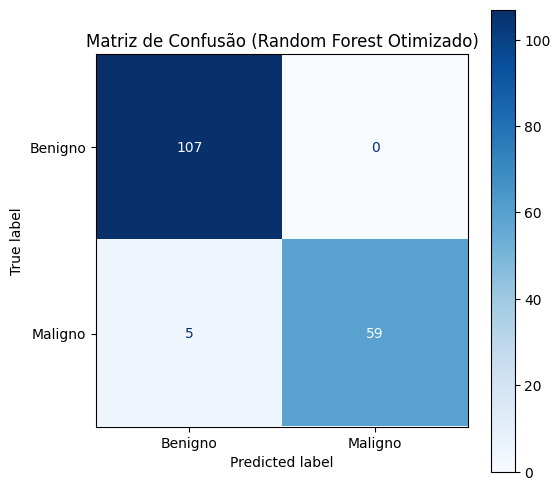


--- Relatório de Classificação do Modelo Random Forest Otimizado ---
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98       107
     Maligno       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [38]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fazendo predições com o modelo otimizado
y_pred_optimized = model_rf_optimized.predict(X_test)

# Exibindo a Matriz de Confusão
print("\n--- Matriz de Confusão do Modelo Random Forest Otimizado ---")
cm = confusion_matrix(y_test, y_pred_optimized)
cmd = ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno'])
fig, ax = plt.subplots(figsize=(6, 6))
cmd.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão (Random Forest Otimizado)')
plt.show()

# Exibindo o Relatório de Classificação
print("\n--- Relatório de Classificação do Modelo Random Forest Otimizado ---")
print(classification_report(y_test, y_pred_optimized, target_names=['Benigno', 'Maligno']))

# 11. Comparação final dos modelos

Apresente uma síntese comparativa.



| Modelo | Métrica principal (Teste) | Outras métricas (Teste) | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| **Baseline (Dummy)** | **Accuracy: 0.6257** | F1-weighted: 0.4817, ROC AUC: 0.5000 | Muito rápido | Previsão da classe majoritária, sem aprendizado. Serve como referência mínima. |
| **Regressão Logística** | **Accuracy: 0.9708** | F1-weighted: 0.9706, ROC AUC: 0.9975 | Rápido (segundos) | Modelo linear, ótima performance após padronização. Baixo risco de overfitting. |
| **Random Forest (Inicial)** | **Accuracy: 0.9708** | F1-weighted: 0.9705, ROC AUC: 0.9951 | Rápido (segundos) | Modelo de árvore, robusto, capta não linearidades. Similar à Regressão Logística sem otimização. |
| **Random Forest (Otimizado)** | **Recall (Maligno): 0.92** | Precision (Maligno): 1.00, F1 (Maligno): 0.96, Accuracy: 0.97 | Moderado (devido à busca) | Otimizado especificamente para maximizar o Recall da classe Maligno (redução de FN), crucial para o problema. |


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| **Seed Utilizada:** `SEED = 42` | Garantir a reprodutibilidade dos resultados em todas as etapas, desde a divisão dos dados até o treinamento do modelo. | Consistência e rastreabilidade dos experimentos. |
| **Remoção da coluna 'id'** | A coluna 'id' é um identificador administrativo, sem valor preditivo, e pode levar a vazamento de dados ou overfitting se mantida. | Evitar que o modelo aprenda padrões irrelevantes; focar em características preditivas. |
| **Codificação do Target (M=1, B=0)** | Converter a variável alvo categórica ('M', 'B') para formato numérico binário para compatibilidade com algoritmos de ML. 'Maligno' como 1 para otimizar o Recall da classe positiva. | Permitir o treinamento de modelos de classificação binária; focar na detecção de casos malignos. |
| **Uso de `SimpleImputer` (mediana)** | Tratar valores ausentes (se existissem) com a mediana, que é robusta a outliers e melhor para dados potencialmente assimétricos. | Garantir que o pipeline seja completo e lide com dados ausentes de forma resiliente. |
| **Uso de `StandardScaler`** | Padronizar as features (média 0, desvio padrão 1) para que modelos baseados em distância ou gradiente não sejam dominados por features com escalas maiores. | Melhorar a performance de modelos como Regressão Logística e acelerar a convergência. |
| **Divisão treino/teste com `stratify=y`** | Dividir os dados em 70% treino e 30% teste, mantendo a proporção original das classes (M/B) em ambos os conjuntos. | Assegurar que ambos os conjuntos representem a distribuição real do target, evitando avaliações enviesadas. |
| **Modelos testados: Baseline, Regressão Logística, Random Forest** | Fornecer um ponto de comparação (baseline) e explorar modelos que representam abordagens diferentes (linear e baseada em árvores). | Avaliar se modelos mais complexos agregam valor em relação a uma solução simples e estabelecer um limite superior de complexidade para o MVP. |
| **Otimização de Random Forest com `RandomizedSearchCV`** | Realizar uma busca eficiente de hiperparâmetros para o Random Forest, focando no `recall_maligno_scorer`. | Encontrar a melhor combinação de hiperparâmetros para maximizar o Recall da classe Maligno. |
| **Hiperparâmetros otimizados (RF)** | `classifier__max_depth`: 11, `classifier__min_samples_leaf`: 4, `classifier__min_samples_split`: 6, `classifier__n_estimators`: 64. | Melhorar o desempenho do Random Forest, especialmente no recall da classe positiva. |
| **Métrica principal: Recall para Maligno** | Priorizar a identificação correta de casos malignos para minimizar falsos negativos, que têm maior impacto clínico. | Direcionar o modelo para a segurança do paciente, reduzindo o risco de diagnósticos tardios de câncer. |
| **Tempo de Treinamento:** Muito rápido (segundos) | O dataset é pequeno (569 instâncias) e os modelos são eficientes. | Atender à restrição prática de baixo custo computacional e agilidade para uso em ambientes clínicos. |
| **Recursos Computacionais:** CPU (padrão Colab) | O problema não exigiu GPUs ou recursos especializados devido ao tamanho do dataset e complexidade dos modelos. | Manter a solução acessível e de baixo custo, sem dependência de hardware avançado. |
| **Limitações Conhecidas** | Pequeno tamanho do dataset (569 instâncias); o modelo é consultivo e não substitui o diagnóstico médico. | Risco de generalização pode ser limitado; necessidade de validação clínica adicional; o modelo serve como ferramenta de apoio, não decisão final. |
| **Tentativas/Descartes** | Não foram feitas tentativas de Deep Learning ou métodos muito avançados, dado o objetivo de MVP e as restrições de simplicidade e custo computacional. | Foco na entrega de um modelo eficaz e simples, aderindo aos objetivos do MVP sem complexidade excessiva. |

# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> **Objetivo do trabalho:** O objetivo deste MVP foi desenvolver um modelo de Machine Learning capaz de classificar tumores de mama como malignos ou benignos, com foco na otimização do *Recall* para a classe maligna, a fim de auxiliar oncologistas na triagem e diagnóstico precoce.

> **Melhor solução encontrada:** O modelo Random Forest otimizado foi a melhor solução, alcançando um *Recall* de 0.92 para a classe maligna no conjunto de teste, com uma precisão de 1.00 e F1-score de 0.96. Essa otimização foi crucial para minimizar os falsos negativos, que são de alto impacto clínico.

> **Comparação com baseline:** Ambos os modelos candidatos (Regressão Logística e Random Forest) superaram drasticamente o baseline (Dummy Classifier), que obteve apenas 62.57% de acurácia, demonstrando que os modelos aprenderam padrões significativos nos dados.

> **Principais aprendizados:**
> - A padronização dos dados é essencial para o bom desempenho de modelos como a Regressão Logística.
> - A estratificação na divisão treino/teste é fundamental em datasets com classes desbalanceadas para garantir a representatividade.
> - A otimização focada em uma métrica específica (Recall para Maligno) permite ajustar o modelo às necessidades clínicas do problema, mesmo quando a acurácia geral já é alta.
> - A EDA confirmou a importância de características como `radius_worst` e `area_worst` na distinção entre tumores, que foram bem capturadas pelos modelos.

> **Limitações:**
> - O tamanho do dataset (569 instâncias) é relativamente pequeno, o que pode limitar a capacidade de generalização do modelo para populações mais diversas.
> - A validação cruzada foi utilizada durante a otimização de hiperparâmetros, mas a avaliação final foi em um único conjunto de teste. Uma validação mais robusta em cenários do mundo real é necessária.
> - O modelo serve como ferramenta de apoio e triagem, não substituindo o diagnóstico e julgamento médico.

> **Próximos passos:**
> - Coletar mais dados para aumentar a robustez e generalização do modelo.
> - Explorar outras técnicas de balanceamento de classes, como SMOTE, se o desbalanceamento se mostrar mais crítico em datasets maiores.
> - Realizar uma validação mais aprofundada com diferentes conjuntos de dados de teste ou através de validação cruzada aninhada.
> - Considerar a interpretabilidade do modelo para fornecer aos médicos insights mais claros sobre as decisões do modelo.
> - Implementar o modelo em um ambiente de produção para testes piloto em um cenário clínico real.
